In [2]:
from datasets import load_dataset

In [12]:
dataset = load_dataset("rungalileo/ragbench", "hotpotqa")

c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\BHUPATHI NADAR\.cache\huggingface\hub\datasets--rungalileo--ragbench. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating validation split: 100%|██████████| 424/424 [00:00<00:00, 

In [15]:
df=dataset["train"].to_pandas()

In [16]:
df.head()

,id,question,documents,response,generation_model_name,annotating_model_name,dataset_name,documents_sentences,response_sentences,sentence_support_information,...,trulens_groundedness,trulens_context_relevance,ragas_faithfulness,ragas_context_relevance,gpt3_adherence,gpt3_context_relevance,gpt35_utilization,relevance_score,utilization_score,completeness_score
0,5a732ab25542991f29ee2d25,In what school district is Governor John R. Ro...,[Governor John R. Rogers High School is a high...,"Governor John R. Rogers High School, named aft...",gpt-3.5-turbo-1106,gpt-4o,hotpotqa_train,"[[[0a, Governor John R. Rogers High School is ...","[[a, Governor John R. Rogers High School, name...",[{'explanation': 'The sentence correctly state...,...,NaN,NaN,NaN,NaN,1.0,0.300000,0.200000,0.200000,0.200000,1.000000
1,5abf8e135542990832d3a14f,whiich Australian racing driver won the 44-lap...,"[Colin Fleming (born April 21, 1984 in San Die...",Daniel Ricciardo won the 44-lap race for the R...,gpt-3.5-turbo-1106,gpt-4o,hotpotqa_train,"[[[0a, Colin Fleming (born April 21, 1984 in S...","[[a, Daniel Ricciardo won the 44-lap race for ...",[{'explanation': 'The sentence is supported by...,...,NaN,NaN,NaN,NaN,1.0,0.157895,0.052632,0.105263,0.105263,1.000000
2,5a89bbb05542992e4fca83a3,What star of Parks and Recreation appeared in ...,[Pioneer Park is a 44-acre (109-ha) city park ...,"Nick Offerman, who played the role of Ron Swan...",gpt-3.5-turbo-1106,gpt-4o,hotpotqa_train,"[[[0a, Pioneer Park is a 44-acre (109-ha) city...","[[a, Nick Offerman, who played the role of Ron...",[{'explanation': 'The sentence claims that Nic...,...,NaN,NaN,NaN,NaN,1.0,0.133333,0.133333,0.133333,0.133333,1.000000
3,5ab56f3e5542992aa134a317,Which genus of flowering plant is found in an ...,[Actaea arizonica is a species of flowering pl...,Crocosmia is found in an environment further s...,gpt-3.5-turbo-1106,gpt-4o,hotpotqa_train,"[[[0a, Actaea arizonica is a species of flower...","[[a, Crocosmia is found in an environment furt...",[{'explanation': 'This sentence asserts that '...,...,NaN,NaN,NaN,NaN,1.0,0.600000,0.100000,0.400000,0.300000,0.750000
4,5ac195455542991316484b40,In what year did the man who shot the Chris St...,[Dennis Bruce Allen (7 November 1951 – 13 Apri...,"Dennis Bruce Allen, the man who shot Chris Sto...",gpt-3.5-turbo-1106,gpt-4o,hotpotqa_train,"[[[0a, Dennis Bruce Allen (7 November 1951 – 1...","[[a, Dennis Bruce Allen, the man who shot Chri...",[{'explanation': 'This sentence claims that De...,...,NaN,NaN,NaN,NaN,1.0,0.080000,0.040000,0.120000,0.080000,0.666667


In [17]:
copy_df=df.copy()

In [18]:
df.columns

Index(['id', 'question', 'documents', 'response', 'generation_model_name',
       'annotating_model_name', 'dataset_name', 'documents_sentences',
       'response_sentences', 'sentence_support_information',
       'unsupported_response_sentence_keys', 'adherence_score',
       'overall_supported_explanation', 'relevance_explanation',
       'all_relevant_sentence_keys', 'all_utilized_sentence_keys',
       'trulens_groundedness', 'trulens_context_relevance',
       'ragas_faithfulness', 'ragas_context_relevance', 'gpt3_adherence',
       'gpt3_context_relevance', 'gpt35_utilization', 'relevance_score',
       'utilization_score', 'completeness_score'],
      dtype='str')

In [21]:
columns_to_drop = [
    "id",
    "generation_model_name",
    "annotating_model_name",
    "dataset_name",
    "documents_sentences",
    "response_sentences",
    "trulens_groundedness",
    "trulens_context_relevance",
    "ragas_faithfulness",
    "ragas_context_relevance",
    "gpt3_adherence",
    "gpt3_context_relevance",
    "gpt35_utilization",
    "relevance_score",
    "utilization_score",
    "completeness_score"
]

copy_df = copy_df.drop(columns=columns_to_drop)

In [23]:
copy_df.sample(10)

,question,documents,response,sentence_support_information,unsupported_response_sentence_keys,adherence_score,overall_supported_explanation,relevance_explanation,all_relevant_sentence_keys,all_utilized_sentence_keys
1159,Ralf Popken had a role in a musical that is a ...,[To Serve and Protect: Privatization and Commu...,"Ralf Popken had a role in the musical ""Chicago...",[{'explanation': 'This sentence accurately com...,[],True,The response makes one primary claim: that Ral...,Document 2 and Document 3 contain useful infor...,"[2a, 2b, 2c, 3a, 3e]","[2b, 2c, 3e]"
1351,Do the documentaries Hot Girls Wanted and The ...,[Hot Girls Wanted is a 2015 American documenta...,"No, the documentaries Hot Girls Wanted and The...",[{'explanation': 'The sentence correctly ident...,[],True,"The response correctly states that ""Hot Girls ...",Document 0 and Document 1 contain useful infor...,"[0a, 1a, 3g]","[0a, 1a, 3g]"
474,Which iPhone was the first to be completely de...,[Jonathan Ornstein is Chairman and Chief Execu...,The iPhone 5 was the first iPhone to be comple...,[{'explanation': 'This sentence is fully suppo...,[],True,The response contains a single sentence claimi...,Documents 1 and 3 contain useful information f...,"[1a, 1d, 3a, 3b]","[1a, 1d, 3a, 3b]"
572,Who was born first of Leslie S. Hiscott and Ja...,[The Satchel Guide was a series of tourist's t...,"Alfred James Rolfe was born first, on December...",[{'explanation': 'The response sentence provid...,[a],False,"The response incorrectly assumes ""Alfred James...",Document 1 contains information about Leslie S...,"[1a, 1b, 2a, 3a]",[2a]
369,Maggie May is a musical based on a folk song a...,"[""Maggie May"" (or ""Maggie Mae"") (Roud 1757) is...","The musical ""Maggie May"" is based on a traditi...",[{'explanation': 'This sentence is fully suppo...,[],True,The response makes one main claim: that the mu...,Documents 0 and 2 contain useful information f...,"[0a, 2a, 2b]","[0a, 2b]"
348,Daniel Walcott was selected by the New York Ra...,"[Luboš Rob (born August 5, 1970) is a Czech pr...",The NHL draft in which Daniel Walcott was sele...,[{'explanation': 'This sentence is supported b...,[],True,The response makes two claims: 1) that Daniel ...,Document 3 is highly relevant because it menti...,"[1b, 3c]","[1b, 3c]"
758,Which British Indian novelist and essayist did...,"[Liana Burgess (born Liliana Macellari, Septem...",Anthony Burgess addressed Salman Rushdie in a ...,[{'explanation': 'The sentence is fully suppor...,[],True,The response sentence states that Anthony Burg...,Document 1 is the primary source of useful inf...,[1a],[1a]
121,"At the 46th Grammy Awards, which award did the...","[Megan Martha ""Meg"" White (born December 10, 1...","The album ""Elephant"" by The White Stripes, whi...",[{'explanation': 'This sentence states that 'E...,[],True,The response is fully supported by the provide...,"Documents 1, 2, and 3 contain useful informati...","[1b, 2b, 3d]","[1b, 2b]"
243,Who played for the 1983–84 New York Knicks sea...,[The 1985–86 New York Knicks season was the 40...,Bernard King played for the 1983–84 New York K...,[{'explanation': 'This sentence states two fac...,[],True,The response states that Bernard King played f...,Documents 1 and 2 contain useful information f...,"[1a, 1d, 2a, 2c]","[2c, 1d]"
788,Who is younger Jenny Bae or Lionel Richie ?,[Jenny Bae (; born 1980) is a South Korean cro...,Jenny Bae is younger than Lionel Richie. She w...,[{'explanation': 'This sentence is supported b...,[],True,The response is supported by the documents. Se...,Document 0 and Document 3 contain useful infor...,"[0a, 3a]","[0a, 3a]"


In [25]:
copy_df.columns

Index(['question', 'documents', 'response', 'sentence_support_information',
       'unsupported_response_sentence_keys', 'adherence_score',
       'overall_supported_explanation', 'relevance_explanation',
       'all_relevant_sentence_keys', 'all_utilized_sentence_keys'],
      dtype='str')

In [40]:
for col in copy_df.columns:
    print(f"{col}:{copy_df[col][0]}")
    print()
    print()

question:In what school district is Governor John R. Rogers High School, named after John Rankin Rogers, located?


documents:['Governor John R. Rogers High School is a high school in the Puyallup School District of Washington, United States. Commonly referred to as "Rogers" or "RHS," the high school is named after former Washington State governor John Rankin Rogers. It was first opened in 1968.'
 'Rogers High School is a 3A public high school located in Rogers, Texas (USA). It is part of the Rogers Independent School District located in southeastern Bell County. In 2013, the school was rated "Met Standard" by the Texas Education Agency.'
 "John Rankin Rogers (September 4, 1838 – December 26, 1901) was the third Governor of the state of Washington. Elected as a member of the People's Party before switching his affiliation to the Democratic Party, Rogers was elected to two consecutive terms in 1896 and 1900, but died before completing his fifth year in office."
 'Wyoming High School is 

In [36]:
copy_df.shape

(1883, 11)

In [37]:
copy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1883 entries, 0 to 1882
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   question                            1883 non-null   str   
 1   documents                           1883 non-null   object
 2   response                            1883 non-null   str   
 3   sentence_support_information        1883 non-null   object
 4   unsupported_response_sentence_keys  1883 non-null   object
 5   adherence_score                     1883 non-null   bool  
 6   overall_supported_explanation       1883 non-null   str   
 7   relevance_explanation               1883 non-null   str   
 8   all_relevant_sentence_keys          1883 non-null   object
 9   all_utilized_sentence_keys          1883 non-null   object
 10  label                               1883 non-null   str   
dtypes: bool(1), object(5), str(5)
memory usage: 1.9+ MB


In [52]:
for num in range(1000):
    if len(copy_df["sentence_support_information"].iloc[num]) >1:
        print(num)
        break

5


In [56]:
for col in copy_df.columns:
    print(f"{col}:{copy_df[col].iloc[5]}")
    print()
    print()

question:Are both American bands The Four Seasons and Local H popular around the Beatles were around?


documents:['Local H\'s Awesome Mix Tape #2 is an extended play by American alternative rock duo Local H, which was released in December 2014 through their merchandiser, G&P Records. Their version of Team was previously released as "The Team EP", which was sold exclusively through live shows and from the official G&P Records website.'
 "UFOFU was a rock band based in Dallas, Texas. The band consisted of Joseph Butcher, and brothers Brandon Curtis and Ben Curtis. It rose to local prominence in the mid-90's through word of mouth and slots opening for other north Texas bands such as Hagfish and Tripping Daisy. While touring, the band opened for Local H, Smoking Popes, The Geraldine Fibbers and Spacehog."
 'The Four Seasons is an American rock and pop band that became internationally successful in the 1960s and 1970s. The Vocal Group Hall of Fame has stated that the group was the most pop

In [53]:
copy_df["sentence_support_information"].iloc[5]

array([{'explanation': "This sentence claims that both bands were popular at the same time as the Beatles. Documents indicate that while The Four Seasons were popular before and during the Beatles' era, Local H was formed long after the Beatles disbanded.", 'fully_supported': False, 'response_sentence_key': 'a', 'supporting_sentence_keys': array([], dtype=object)},
       {'explanation': "This sentence correctly states that The Four Seasons were noted as the most popular rock band before the Beatles. However, it incorrectly implies that Local H's formation in the late 1980s makes their popularity overlap with the Beatles' era, which ended in 1970.", 'fully_supported': False, 'response_sentence_key': 'b', 'supporting_sentence_keys': array([], dtype=object)}],
      dtype=object)

In [ ]:
def get_grounding_label(row):
    support_info = row["sentence_support_information"]

    # Handle missing values
    if support_info is None:
        return None

    if hasattr(support_info, "tolist"):
        support_info = support_info.tolist()

    # Empty annotation
    if len(support_info) == 0:
        return None

    # Count supported sentences
    supported = sum(
        item.get("fully_supported", False)
        for item in support_info
        if isinstance(item, dict)
    )

    # Total response sentences
    total = len(support_info)

    if supported == total:
        return "GROUNDED"

    elif supported > 0:
        return "PARTIALLY_GROUNDED"

    else:
        return "HALLUCINATED"

In [33]:
copy_df["label"] = copy_df.apply(get_grounding_label, axis=1)

In [34]:
copy_df["label"].value_counts()

label
GROUNDED              1724
HALLUCINATED           140
PARTIALLY_GROUNDED      19
Name: count, dtype: int64

In [38]:
copy_df.isnull().sum()

question                              0
documents                             0
response                              0
sentence_support_information          0
unsupported_response_sentence_keys    0
adherence_score                       0
overall_supported_explanation         0
relevance_explanation                 0
all_relevant_sentence_keys            0
all_utilized_sentence_keys            0
label                                 0
dtype: int64

In [58]:
copy_df.columns

Index(['question', 'documents', 'response', 'sentence_support_information',
       'unsupported_response_sentence_keys', 'adherence_score',
       'overall_supported_explanation', 'relevance_explanation',
       'all_relevant_sentence_keys', 'all_utilized_sentence_keys', 'label'],
      dtype='str')

In [59]:
drop_cols = [
    "sentence_support_information",
    "unsupported_response_sentence_keys",
    "adherence_score",
    "overall_supported_explanation",
    "relevance_explanation",
    "all_relevant_sentence_keys",
    "all_utilized_sentence_keys",
]

copy_df = copy_df.drop(columns=drop_cols)

In [ ]:
copy_df.columns

Index(['question', 'documents', 'response', 'label'], dtype='str')

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
copy_df.isnull().sum()

question     0
documents    0
response     0
label        0
dtype: int64

In [64]:
copy_df['label'].unique()

<ArrowStringArray>
['GROUNDED', 'HALLUCINATED', 'PARTIALLY_GROUNDED']
Length: 3, dtype: str

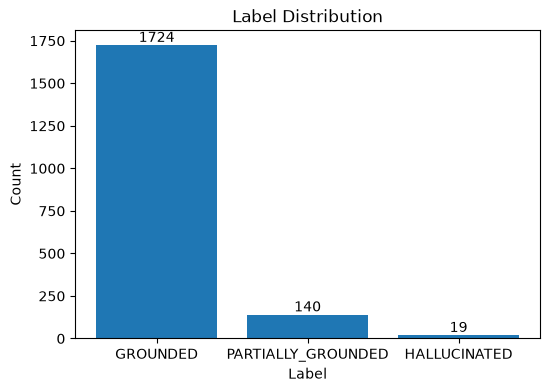

In [65]:
label_counts= copy_df["label"].value_counts()
plt.figure(figsize=(6, 4))
bars=plt.bar(
    ["GROUNDED", "PARTIALLY_GROUNDED","HALLUCINATED"],
    label_counts.values
)
plt.bar_label(bars)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [68]:
for col in copy_df.columns:
    print(f"{col}:{copy_df[col].iloc[3]}")
    print()
    print()

question:Which genus of flowering plant is found in an environment further south, Crocosmia or Cimicifuga?


documents:['Actaea arizonica is a species of flowering plant in the buttercup family known by the common name Arizona bugbane. It is endemic to Arizona in the United States, where it occurs in Coconino, Gila, and Yavapai Counties. Like some other species in genus "Actaea", this plant was formerly included in the genus "Cimicifuga".'
 'Crocosmia paniculata (Aunt Eliza) is a bulbous flowering plant that is native to eastern South Africa, Lesotho, and Swaziland, growing in wet areas by streams, marshes, and drainages. Plants reach 4 to 5 ft (1.2–1.5 m) tall, with lanceolate leaves and deep orange to orange-brown flowers. It is a popular ornamental plant.'
 'Crocosmia ( ; J. E. Planchon, 1851) (montbretia) is a small genus of flowering plants in the iris family, Iridaceae. It is native to the grasslands of southern and eastern Africa, ranging from South Africa to Sudan. One species 

In [ ]:
copy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1883 entries, 0 to 1882
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   question   1883 non-null   str   
 1   documents  1883 non-null   object
 2   response   1883 non-null   str   
 3   label      1883 non-null   str   
dtypes: object(1), str(3)
memory usage: 462.0+ KB


In [73]:
copy_df["documents"].head().apply(type)

0    <class 'numpy.ndarray'>
1    <class 'numpy.ndarray'>
2    <class 'numpy.ndarray'>
3    <class 'numpy.ndarray'>
4    <class 'numpy.ndarray'>
Name: documents, dtype: object

In [74]:
import numpy as np

In [75]:
copy_df["documents"] = copy_df["documents"].apply(
    lambda x: x.tolist() if isinstance(x, np.ndarray) else x
)

In [76]:
copy_df["documents"].head().apply(type)

0    <class 'list'>
1    <class 'list'>
2    <class 'list'>
3    <class 'list'>
4    <class 'list'>
Name: documents, dtype: object

In [78]:
temp = copy_df.copy()

temp["documents"] = temp["documents"].apply(str)

temp.duplicated(
    subset=["question", "documents", "response", "label"]
).sum()

np.int64(0)

In [79]:
temp.duplicated(
    subset=["question", "response", "label"]
).sum()

np.int64(0)

In [80]:
copy_df["documents"] = copy_df["documents"].apply(
    lambda x: np.array(x) if isinstance(x, list) else x
)

In [82]:
copy_df.tail()

,question,documents,response,label
1878,Larry Mosley and his cousin Shane Mosley both ...,"[Larry Dennis Mosley (born December 26, 1979) ...",Both Larry Mosley and his cousin Shane Mosley ...,GROUNDED
1879,Hoy Es Manana is by what Mexican Actress and s...,"[¿Hoy Es Mañana? (""Today is Tomorrow?"") is the...","The album ""Hoy Es Mañana"" is by the Mexican ac...",GROUNDED
1880,Joan Baez's hit recording from Quad Studios Na...,[Joan Baez is the self-titled debut album by f...,"The hit recording of ""The Night They Drove Old...",HALLUCINATED
1881,National Stadium BTS Station is near the shopp...,[Sukhumvit MRT Station (Thai: สถานีสุขุมวิท ) ...,National Stadium BTS Station is near the shopp...,GROUNDED
1882,SS Ionic was built by the industrial company b...,[SS Ionic was a steam-powered ocean liner buil...,SS Ionic was built by the industrial company b...,GROUNDED


In [136]:
copy_df.to_csv(r"C:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\Data\data.csv", index=False)